# imports

In [9]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

conn = duckdb.connect('../../database/financial_data.duckdb')

query = "SELECT * FROM gold_ml_features WHERE asset_symbol = 'AAPL' AND interval = '1h' ORDER BY date"
df = conn.execute(query).df()

print(f"Total Rows with Macro Data: {len(df)}")
df.tail()

Total Rows with Macro Data: 2850


,asset_symbol,asset_class,exchange,interval,date,open,high,low,close,volume,...,log_returns,hl_ratio,close_position,prev_close,prev_volume,prev_high,prev_low,dxy_close,vix_close,tnx_close
2845,AAPL,Stock,Yahoo Finance,1h,2026-05-11 14:30:00,292.045013,293.589996,291.750000,293.369904,4290117.0,...,0.004526,0.006272,0.880384,292.045013,9227947.0,293.149994,290.230011,97.894997,18.059999,4.392
2846,AAPL,Stock,Yahoo Finance,1h,2026-05-11 15:30:00,293.369995,293.880005,291.821411,292.415009,3777650.0,...,-0.003260,0.007040,0.288351,293.369904,4290117.0,293.589996,291.750000,97.889000,17.940001,4.392
2847,AAPL,Stock,Yahoo Finance,1h,2026-05-11 16:30:00,292.415009,292.704987,290.630005,291.940002,3556324.0,...,-0.001626,0.007108,0.631330,292.415009,3777650.0,293.880005,291.821411,97.939003,18.110001,4.408
2848,AAPL,Stock,Yahoo Finance,1h,2026-05-11 17:30:00,291.939911,292.980011,291.725006,291.739990,2587000.0,...,-0.000685,0.004302,0.011940,291.940002,3556324.0,292.704987,290.630005,97.911003,18.160000,4.404
2849,AAPL,Stock,Yahoo Finance,1h,2026-05-11 18:30:00,291.739990,292.209900,290.859985,292.149994,2874040.0,...,0.001404,0.004621,0.955622,291.739990,2587000.0,292.980011,291.725006,97.955002,18.280001,4.410


In [10]:
print("--- AAPL 1h Date Range ---")
print(conn.execute("SELECT MIN(date), MAX(date) FROM gold_financial_analytics WHERE asset_symbol='AAPL' AND interval='1h'").df())

print("\n--- Macro 1h Date Range ---")
print(conn.execute("SELECT MIN(date), MAX(date) FROM clean_macro_features WHERE interval='1h'").df())

--- AAPL 1h Date Range ---
            min(date)           max(date)
0 2024-04-03 13:30:00 2026-05-11 19:30:00

--- Macro 1h Date Range ---
            min(date)           max(date)
0 2024-06-13 04:00:00 2026-05-14 10:00:00


In [11]:
print("--- BTC 1h Sample ---")
display(conn.execute("SELECT date FROM gold_financial_analytics WHERE asset_symbol='BTC' AND interval='1h' LIMIT 5").df())

print("\n--- Macro 1h Sample ---")
display(conn.execute("SELECT date FROM clean_macro_features WHERE interval='1h' LIMIT 5").df())


--- BTC 1h Sample ---


,date
0,2020-03-25 10:00:00
1,2020-03-25 11:00:00
2,2020-03-25 12:00:00
3,2020-03-25 13:00:00
4,2020-03-25 14:00:00



--- Macro 1h Sample ---


,date
0,2024-06-13 07:00:00
1,2024-06-13 08:00:00
2,2024-06-13 09:00:00
3,2024-06-13 10:00:00
4,2024-06-13 11:00:00


In [12]:
conn.execute("SELECT COUNT(*) FROM gold_ml_features WHERE asset_symbol = 'BTC' AND interval = '1h'").df()

,count_star()
0,3341


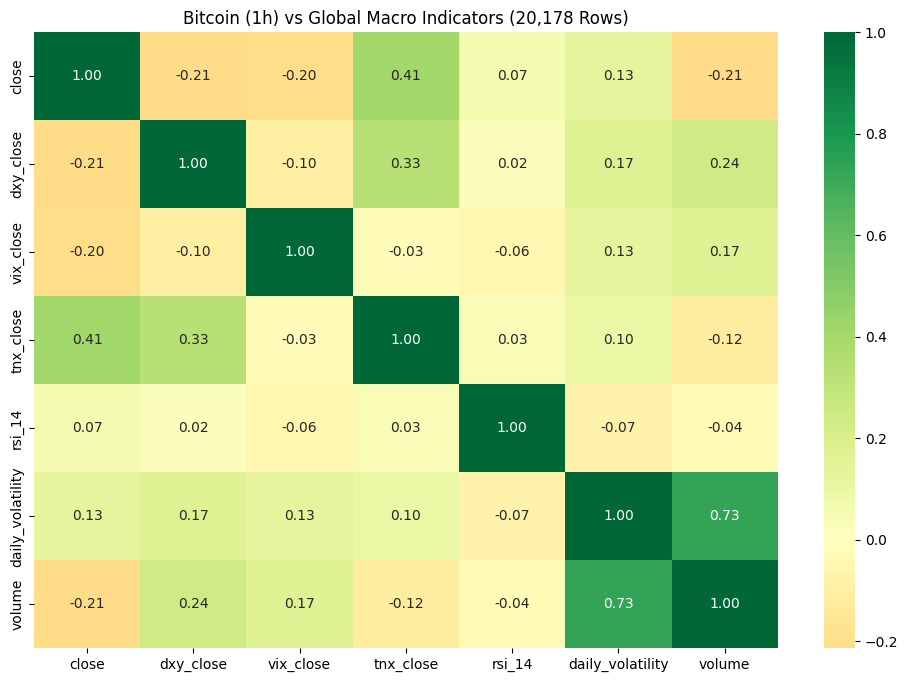


--- Correlation with BTC Price ---
close               1.000000
tnx_close           0.407871
daily_volatility    0.131132
rsi_14              0.065882
vix_close          -0.199955
dxy_close          -0.211439
volume             -0.213856
Name: close, dtype: float64


In [13]:
query = "SELECT * FROM gold_ml_features WHERE asset_symbol = 'BTC' AND interval = '1h' ORDER BY date"
df_btc = conn.execute(query).df()
analysis_cols = [
    'close', 'dxy_close', 'vix_close', 'tnx_close', 
    'rsi_14', 'daily_volatility', 'volume'
]
corr = df_btc[analysis_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title('Bitcoin (1h) vs Global Macro Indicators (20,178 Rows)')
plt.show()
print("\n--- Correlation with BTC Price ---")
print(corr['close'].sort_values(ascending=False))

In [14]:
query = """
SELECT 
    asset_symbol, 
    MIN(date) as start_date, 
    MAX(date) as end_date, 
    COUNT(*) as total_rows,
    COUNT(dxy_close) as rows_with_dxy,
    COUNT(vix_close) as rows_with_vix
FROM gold_ml_features 
WHERE asset_symbol = 'BTC' AND interval = '1h'
GROUP BY 1
"""
display(conn.execute(query).df())

,asset_symbol,start_date,end_date,total_rows,rows_with_dxy,rows_with_vix
0,BTC,2024-06-13 12:00:00,2026-05-13 18:00:00,3341,3341,3341


In [15]:
query_aapl = """
SELECT 
    asset_symbol, 
    MIN(date) as start_date, 
    MAX(date) as end_date, 
    COUNT(*) as total_rows,
    COUNT(dxy_close) as rows_with_dxy,
    COUNT(vix_close) as rows_with_vix
FROM gold_ml_features 
WHERE asset_symbol = 'AAPL' AND interval = '1h'
GROUP BY 1
"""
display(conn.execute(query_aapl).df())

,asset_symbol,start_date,end_date,total_rows,rows_with_dxy,rows_with_vix
0,AAPL,2024-06-13 13:30:00,2026-05-11 18:30:00,2850,2850,2850


In [16]:
query_all = """
SELECT 
    asset_symbol, 
    COUNT(*) as total_rows,
    COUNT(dxy_close) as dxy_rows,
    COUNT(vix_close) as vix_rows,
    COUNT(tnx_close) as tnx_rows
FROM gold_ml_features 
WHERE asset_symbol IN ('BTC', 'AAPL') AND interval = '1h'
GROUP BY 1
"""
display(conn.execute(query_all).df())

,asset_symbol,total_rows,dxy_rows,vix_rows,tnx_rows
0,BTC,3341,3341,3341,3341
1,AAPL,2850,2850,2850,2850


In [17]:
print("--- AAPL 1h: Macro Alignment Proof ---")
query_aapl_proof = """
SELECT date, close, dxy_close, vix_close, tnx_close 
FROM gold_ml_features 
WHERE asset_symbol = 'AAPL' AND interval = '1h' 
ORDER BY date 
LIMIT 10
"""
display(conn.execute(query_aapl_proof).df())

print("\n--- BTC 1h: Macro Alignment Proof ---")
query_btc_proof = """
SELECT date, close, dxy_close, vix_close, tnx_close 
FROM gold_ml_features 
WHERE asset_symbol = 'BTC' AND interval = '1h' 
ORDER BY date 
LIMIT 10
"""
display(conn.execute(query_btc_proof).df())


--- AAPL 1h: Macro Alignment Proof ---


,date,close,dxy_close,vix_close,tnx_close
0,2024-06-13 13:30:00,213.850204,104.936996,12.13,4.275
1,2024-06-13 14:30:00,213.445007,105.029999,12.39,4.275
2,2024-06-13 15:30:00,212.100006,105.103996,12.31,4.248
3,2024-06-13 16:30:00,213.600006,105.255997,12.45,4.237
4,2024-06-13 17:30:00,213.190002,105.195000,12.17,4.252
5,2024-06-13 18:30:00,214.339996,105.195999,11.94,4.238
6,2024-06-14 13:30:00,213.389999,105.791000,12.52,4.207
7,2024-06-14 14:30:00,213.595001,105.663002,12.93,4.207
8,2024-06-14 15:30:00,211.750000,105.554001,12.81,4.217
9,2024-06-14 16:30:00,211.779999,105.536003,12.59,4.223



--- BTC 1h: Macro Alignment Proof ---


,date,close,dxy_close,vix_close,tnx_close
0,2024-06-13 12:00:00,67729.1,104.860001,12.06,4.264
1,2024-06-13 13:00:00,67576.1,104.936996,12.13,4.275
2,2024-06-13 14:00:00,67344.7,105.029999,12.39,4.275
3,2024-06-13 15:00:00,66433.1,105.103996,12.31,4.248
4,2024-06-13 16:00:00,66950.1,105.255997,12.45,4.237
5,2024-06-13 17:00:00,66885.7,105.195000,12.17,4.252
6,2024-06-13 18:00:00,66838.5,105.195999,11.94,4.238
7,2024-06-14 12:00:00,67062.3,105.633003,12.72,4.219
8,2024-06-14 13:00:00,67050.0,105.791000,12.52,4.207
9,2024-06-14 14:00:00,66948.9,105.663002,12.93,4.207


In [18]:
print("--- SOURCE: Raw Macro Table (clean_macro_features) ---")
query_source = """
SELECT date, dxy_close, vix_close, tnx_close 
FROM clean_macro_features 
WHERE interval = '1h' AND date BETWEEN '2024-06-13 12:00:00' AND '2024-06-13 15:00:00'
ORDER BY date
"""
display(conn.execute(query_source).df())

print("\n--- FINAL: Joined Apple Table (gold_ml_features) ---")
query_final = """
SELECT date, close, dxy_close, vix_close, tnx_close 
FROM gold_ml_features 
WHERE asset_symbol = 'AAPL' AND interval = '1h' 
  AND date BETWEEN '2024-06-13 12:00:00' AND '2024-06-13 15:00:00'
ORDER BY date
"""
display(conn.execute(query_final).df())


--- SOURCE: Raw Macro Table (clean_macro_features) ---


,date,dxy_close,vix_close,tnx_close
0,2024-06-13 12:00:00,104.860001,12.06,NaN
1,2024-06-13 12:20:00,NaN,NaN,4.264
2,2024-06-13 13:00:00,104.936996,12.13,NaN
3,2024-06-13 13:20:00,NaN,NaN,4.275
4,2024-06-13 14:00:00,105.029999,12.39,NaN
5,2024-06-13 14:20:00,NaN,NaN,4.275
6,2024-06-13 15:00:00,105.103996,12.31,NaN



--- FINAL: Joined Apple Table (gold_ml_features) ---


,date,close,dxy_close,vix_close,tnx_close
0,2024-06-13 13:30:00,213.850204,104.936996,12.13,4.275
1,2024-06-13 14:30:00,213.445007,105.029999,12.39,4.275


In [19]:
conn.close()